## Notebook 4 — 2012-drought weather, fitted yields by low-till duration
## Fig 5 (a)

### Prerequisites
This notebook reads *model output*, not just raw data. Run these first:

| needed | produced by |
|---|---|
| `output_linear_1999_2023/3_1_corn_low_till_duration_weather_binning_edd69/` | `3_1_ols_corn_low_till_duration_edd69_binned.R` |
| `output_linear_1999_2023/3_2_soy_low_till_duration_weather_binning_edd69/` | `3_2_ols_soy_low_till_duration_edd69_binned.R` |
| `data/Field_yield_tillage/processed_smooth_1999_2023/` | provided |
| `data/PRISM/PRISM_climate_1999_2023.csv` | provided |
| `data/irrigation/field_irrigation_ever_only_irrigated.csv` | provided |

Those folders must contain `*_effects.csv`, `*_duration_weather_slopes.csv`,
`*_control_weather_slopes.csv`, `*_additive_control_terms.csv`, `*_bin_stats.csv`,
`*_terms.csv`, `*_field_fixed_effects.csv` and `*_year_fixed_effects.csv`.

### Run order
Top to bottom, from a fresh kernel. Cells are chunked over the state panels
(`CHUNKSIZE = 1_000_000`), so peak memory stays moderate but the read is the slow part.

### Duration reconstruction
`duration_2012` is reconstructed from the 2023 record as
`max(duration_2023 - 11, 0)` for continuous low-till fields and `0` otherwise. This is
exact rather than imputed, because every field in the sample is either a clean control
in 2023 or in a single unbroken spell. The notebook cross-checks the reconstruction
against fields that do have an observed 2012 record and asserts zero disagreement — do
not remove that assert.


# 2012 Weather Counterfactual: Full Model-Fitted Yields

This fully self-contained notebook estimates full model-fitted corn and soybean yields under two weather conditions:

1. mean observed weather during 2010-2019;
2. observed weather in the 2012 drought year.

Each weather condition is combined with four low-till duration assumptions:

- no low till (`0` years);
- actual observed 2012 duration;
- actual observed 2023 duration;
- continued 2023 low till through 2035.

The same fields eligible in 2023 are used in every scenario. Fields without a valid eligible 2012 record receive a 2012 duration of zero. All scenarios use the estimated 2012 year fixed effect, allowing the comparisons to isolate weather and duration differences. Fitted yields include field and year fixed effects, the EDD-bin main effect, bin-specific duration and centered-EDD terms, the duration-by-EDD interaction, and raw additive weather-control terms.

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")

# ============================== PORTABLE PATHS ==============================
# Set ROOT_OVERRIDE to the folder that contains "data/", or leave it "" to let the
# notebook find the project automatically (it searches the working directory and its
# parents, so it works as long as the notebook lives inside the project folder).
#
#   Google Drive (Mac)      "/Users/<you>/Library/CloudStorage/GoogleDrive-<you>@stanford.edu/My Drive/Research/Tillage_trend/Codex"
#   Google Drive (Windows)  "G:/My Drive/Research/Tillage_trend/Codex"
#   Colab                   mount the drive first, then point at the mounted path
ROOT_OVERRIDE = ""


def _find_project_root():
    import os as _os
    from pathlib import Path as _P

    def _ok(p):
        p = _P(p)
        return ((p / "data" / "Field_yield_tillage" / "processed_smooth_1999_2023").is_dir()
                and (p / "data" / "PRISM" / "PRISM_climate_1999_2023.csv").is_file())

    if ROOT_OVERRIDE:
        if not _ok(ROOT_OVERRIDE):
            raise FileNotFoundError(
                "ROOT_OVERRIDE is set to %r but that folder does not contain\n"
                "  data/Field_yield_tillage/processed_smooth_1999_2023/  and\n"
                "  data/PRISM/PRISM_climate_1999_2023.csv\n"
                "Fix the path, or set ROOT_OVERRIDE = \"\" for automatic detection."
                % ROOT_OVERRIDE)
        return _P(ROOT_OVERRIDE).resolve()

    seeds = []
    env = _os.environ.get("PROJECT_ROOT", "")
    if env:
        seeds.append(_P(env))
    for key in ("__vsc_ipynb_file__",):          # VS Code notebooks
        v = globals().get(key)
        if v:
            seeds.append(_P(v).parent)
    try:                                          # when exported to .py
        seeds.append(_P(__file__).parent)
    except NameError:
        pass
    seeds.append(_P.cwd())                        # Jupyter: the notebook's folder

    tried = []
    for s in seeds:
        for c in [s, *s.parents]:
            if c in tried:
                continue
            tried.append(c)
            if _ok(c):
                return _P(c).resolve()
    raise FileNotFoundError(
        "Could not locate the project root. Set ROOT_OVERRIDE at the top of this "
        "cell to the folder containing data/.\nSearched %d folder(s), starting from: %s"
        % (len(tried), ", ".join(str(t) for t in tried[:3])))


ROOT = _find_project_root()
print("Project root:", ROOT)
# ============================================================================
FIELD_DIR = ROOT / "data" / "Field_yield_tillage" / "processed_smooth_1999_2023"
PRISM_PATH = ROOT / "data" / "PRISM" / "PRISM_climate_1999_2023.csv"
OUTPUT_DIR = ROOT / "output_scenario_1999_2023" / "drought_2012_weather_fitted_yields_duration_scenarios_no_irrigation"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CROPS = ["corn", "soy"]
CROP_LABELS = {"corn": "Corn", "soy": "Soybean"}
CHUNKSIZE = 1_000_000

FOCAL_WEATHER_VAR = "EDD_6_9"
OTHER_WEATHER_CONTROL_VARS = ["GDD_4_5", "PPT_4_5", "GDD_6_9", "PPT_6_9"]
WEATHER_VARS = [*OTHER_WEATHER_CONTROL_VARS, FOCAL_WEATHER_VAR]
WEATHER_SOURCE_COLS = {
    "GDD_4_5": "GDD_4_5",
    "PPT_4_5": "ppt_4_5",
    "GDD_6_9": "GDD_6_9",
    "PPT_6_9": "ppt_6_9",
    "EDD_6_9": "EDD_6_9",
}

AVERAGE_WEATHER_YEARS = list(range(2010, 2020))
REFERENCE_YEAR_FE = 2012
FUTURE_DURATION_YEAR = 2035
BASE_DURATION_YEAR = 2023
YEARS_TO_ADD = FUTURE_DURATION_YEAR - BASE_DURATION_YEAR

# Reference year for the historical-duration arm.  Distinct from
# REFERENCE_YEAR_FE, which selects the year fixed effect.
HISTORICAL_DURATION_YEAR = 2012
YEARS_BACK = BASE_DURATION_YEAR - HISTORICAL_DURATION_YEAR

DURATION_ORDER = [
    "No low till",
    "2012 duration",
    "2023 duration",
    "Continued low till",
]
WEATHER_ORDER = [
    "2010-2019 average weather",
    "2012 weather",
]


def find_one(directory: Path, patterns: list[str]) -> Path:
    matches = []
    for pattern in patterns:
        matches.extend(sorted(directory.glob(pattern)))
    matches = sorted(set(matches))
    if not matches:
        raise FileNotFoundError(f"No file matching {patterns} found in {directory}")
    if len(matches) > 1:
        print("Multiple matches found; using first:")
        for match in matches:
            print("  ", match.name)
    return matches[0]


MODEL_DIRS = {
    "corn": ROOT / "output_linear_1999_2023" / "3_1_corn_low_till_duration_weather_binning_edd69",
    "soy": ROOT / "output_linear_1999_2023" / "3_2_soy_low_till_duration_weather_binning_edd69",
}
IRRIGATION_HISTORY_PATH = ROOT / "data" / "irrigation" / "field_irrigation_ever_only_irrigated.csv"
STATES = ["IA", "IL", "IN", "MI", "MN", "MO", "OH", "SD", "WI"]
FIELD_FILES = {
    crop: [
        FIELD_DIR / f"{crop}_yield_tillage_{state}_1999_2023.csv"
        for state in STATES
    ]
    for crop in CROPS
}

USECOLS = [
    "OBJECTID", "yield", "size", "year", "till", "GEOID",
    "till_1_count", "till_1_streak", "till_0_count", "till_0_streak",
]

print(f"Project root: {ROOT}")
print(f"Output directory: {OUTPUT_DIR}")


Project root: /Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex
Output directory: /Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex/output_scenario_1999_2023/drought_2012_weather_fitted_yields_duration_scenarios_no_irrigation


## Load Shared Model Inputs

In [2]:
# Load all coefficient tables directly from the model-output CSV files.
def pick_column(df: pd.DataFrame, candidates: list[str], role: str, required: bool = True):
    normalized = {re.sub(r"[^a-z0-9]+", "", c.lower()): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        key = re.sub(r"[^a-z0-9]+", "", cand.lower())
        if key in normalized:
            return normalized[key]
    if required:
        raise ValueError(f"Could not identify {role}. Available columns: {df.columns.tolist()}")
    return None


def standardize_slope_table(df: pd.DataFrame, estimate_candidates: list[str], se_candidates: list[str], estimate_out: str, se_out: str) -> pd.DataFrame:
    weather_col = pick_column(df, ["weather_var", "weather_variable", "weather_source_var", "variable", "var"], "weather variable column")
    bin_col = pick_column(df, ["weather_bin", "bin", "bin_label", "category"], "weather bin column")
    estimate_col = pick_column(df, estimate_candidates, estimate_out)
    se_col = pick_column(df, se_candidates, se_out)
    out = df.rename(columns={weather_col: "weather_var", bin_col: "weather_bin", estimate_col: estimate_out, se_col: se_out}).copy()
    out["weather_var"] = out["weather_var"].astype(str)
    out["weather_bin"] = out["weather_bin"].astype(str)
    out[estimate_out] = pd.to_numeric(out[estimate_out], errors="coerce")
    out[se_out] = pd.to_numeric(out[se_out], errors="coerce")
    return out[["weather_var", "weather_bin", estimate_out, se_out]]


def normalize_weather_name(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    for weather_var in WEATHER_VARS:
        if weather_var.lower() in text.lower():
            return weather_var
    return text


def standardize_duration_effects(df: pd.DataFrame, crop: str) -> pd.DataFrame:
    weather_col = pick_column(df, ["weather_var", "weather_source_var", "weather_variable", "variable", "var"], "weather variable column")
    bin_col = pick_column(df, ["weather_bin", "bin", "bin_label", "category"], "weather bin column")
    estimate_col = pick_column(
        df,
        ["estimate_log_points_per_year", "estimate", "effect", "coef", "coefficient", "tillage_duration_effect", "duration_effect", "log_yield_effect"],
        "per-year tillage duration effect estimate",
    )
    se_col = pick_column(df, ["std_error", "std.error", "se", "stderr", "standard_error", "effect_std_error", "duration_effect_std_error"], "per-year tillage duration effect standard error")
    out = df.copy()
    out["weather_var"] = out[weather_col].map(normalize_weather_name)
    out = out.loc[out["weather_var"].eq(FOCAL_WEATHER_VAR)].copy()
    out["weather_bin"] = out[bin_col].astype(str)
    out["tillage_duration_effect_per_year"] = pd.to_numeric(out[estimate_col], errors="coerce")
    out["tillage_duration_effect_per_year_std_error"] = pd.to_numeric(out[se_col], errors="coerce")
    out = out[["weather_var", "weather_bin", "tillage_duration_effect_per_year", "tillage_duration_effect_per_year_std_error"]].drop_duplicates()
    out["crop"] = crop
    return out


def standardize_additive_control_terms(df: pd.DataFrame, crop: str) -> pd.DataFrame:
    focal_col = pick_column(df, ["weather_var", "focal_weather_source_var", "focal_weather_var", "binned_weather_var", "weather_var_binned", "bin_weather_var", "focal_var"], "focal weather variable column")
    control_col = pick_column(df, ["additive_control", "control_weather_var", "control_var", "other_weather_var", "term", "variable", "var"], "additive weather control variable column")
    estimate_col = pick_column(df, ["estimate", "coef", "coefficient", "effect", "slope", "control_weather_slope", "additive_control_term"], "additive weather control estimate")
    se_col = pick_column(df, ["std_error", "std.error", "se", "stderr", "standard_error", "control_weather_slope_std_error", "additive_control_term_std_error"], "additive weather control standard error")
    out = df.copy()
    out["focal_weather_var"] = out[focal_col].map(normalize_weather_name)
    out = out.loc[out["focal_weather_var"].eq(FOCAL_WEATHER_VAR)].copy()
    out["control_weather_var"] = out[control_col].map(normalize_weather_name)
    out = out.loc[out["control_weather_var"].isin(OTHER_WEATHER_CONTROL_VARS)].copy()
    out["additive_control_slope"] = pd.to_numeric(out[estimate_col], errors="coerce")
    out["additive_control_slope_std_error"] = pd.to_numeric(out[se_col], errors="coerce")
    out = out[["control_weather_var", "additive_control_slope", "additive_control_slope_std_error"]].drop_duplicates()
    if out.empty:
        raise ValueError(f"No usable additive weather-control terms found for {crop} after filtering focal variable to {FOCAL_WEATHER_VAR}.")
    out["crop"] = crop
    return out


def standardize_bin_main_effects(df: pd.DataFrame, crop: str) -> pd.DataFrame:
    weather_col = pick_column(df, ["weather_var", "weather_source_var", "weather_variable", "variable", "var"], "weather variable column")
    term_col = pick_column(df, ["term", "coefficient", "coef_name", "name"], "term column")
    estimate_col = pick_column(df, ["estimate", "coef", "coefficient", "effect"], "weather-bin main effect estimate")
    se_col = pick_column(df, ["std_error", "std.error", "se", "stderr", "standard_error"], "weather-bin main effect standard error")
    out = df.copy()
    out["weather_var"] = out[weather_col].map(normalize_weather_name)
    out = out.loc[out["weather_var"].eq(FOCAL_WEATHER_VAR)].copy()
    out["term"] = out[term_col].astype(str)
    out = out.loc[out["term"].isin(["bin_middle", "bin_high"])].copy()
    out["weather_bin"] = out["term"].str.replace("bin_", "", regex=False)
    out["bin_main_effect"] = pd.to_numeric(out[estimate_col], errors="coerce")
    out["bin_main_effect_std_error"] = pd.to_numeric(out[se_col], errors="coerce")
    out = out[["weather_var", "weather_bin", "bin_main_effect", "bin_main_effect_std_error"]].drop_duplicates()
    low_row = pd.DataFrame({
        "weather_var": [FOCAL_WEATHER_VAR],
        "weather_bin": ["low"],
        "bin_main_effect": [0.0],
        "bin_main_effect_std_error": [0.0],
    })
    out = pd.concat([low_row, out], ignore_index=True)
    out["crop"] = crop
    return out


def load_coefficients_for_crop(crop: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    results_dir = MODEL_DIRS[crop]
    prefix = f"{crop}_linear_duration_weather_binning_edd69_with_other_weather_controls"
    paths = {
        "effects": results_dir / f"{prefix}_effects.csv",
        "control_weather_slopes": results_dir / f"{prefix}_control_weather_slopes.csv",
        "duration_weather_slopes": results_dir / f"{prefix}_duration_weather_slopes.csv",
        "additive_control_terms": results_dir / f"{prefix}_additive_control_terms.csv",
        "bin_stats": results_dir / f"{prefix}_bin_stats.csv",
        "terms": results_dir / f"{prefix}_terms.csv",
    }
    missing_paths = [name for name, path in paths.items() if not path.exists()]
    if missing_paths:
        raise FileNotFoundError(f"Missing expected {crop} model output files: {missing_paths}\n{paths}")

    effects_raw = pd.read_csv(paths["effects"])
    control_raw = pd.read_csv(paths["control_weather_slopes"])
    duration_raw = pd.read_csv(paths["duration_weather_slopes"])
    additive_raw = pd.read_csv(paths["additive_control_terms"])
    bins = pd.read_csv(paths["bin_stats"])
    terms_raw = pd.read_csv(paths["terms"])

    control = standardize_slope_table(
        control_raw,
        estimate_candidates=["control_weather_slope", "weather_slope", "slope", "estimate", "coef", "coefficient"],
        se_candidates=["control_weather_slope_std_error", "control_weather_slope_se", "std_error", "std.error", "se", "stderr", "standard_error"],
        estimate_out="edd_control_weather_slope",
        se_out="edd_control_weather_slope_std_error",
    )
    duration = standardize_slope_table(
        duration_raw,
        estimate_candidates=["slope_log_points_per_year_per_weather_unit", "duration_weather_slope", "low_till_duration_weather_slope", "slope", "estimate", "coef", "coefficient"],
        se_candidates=["slope_std_error", "duration_weather_slope_std_error", "duration_weather_slope_se", "std_error", "std.error", "se", "stderr", "standard_error"],
        estimate_out="edd_duration_weather_slope",
        se_out="edd_duration_weather_slope_std_error",
    )
    required_bin_cols = {"weather_var", "weather_bin", "weather_min", "weather_max", "weather_median", "trimmed_sample_p05", "trimmed_sample_p95"}
    missing = required_bin_cols - set(bins.columns)
    if missing:
        raise ValueError(f"{crop} bin_stats is missing columns: {sorted(missing)}")

    edd_bins = bins.loc[bins["weather_var"].eq(FOCAL_WEATHER_VAR)].copy()
    edd_coef = control.loc[control["weather_var"].eq(FOCAL_WEATHER_VAR)].merge(
        duration.loc[duration["weather_var"].eq(FOCAL_WEATHER_VAR)],
        on=["weather_var", "weather_bin"],
        how="left",
    ).merge(
        edd_bins[["weather_var", "weather_bin", "weather_min", "weather_max", "weather_median", "trimmed_sample_p05", "trimmed_sample_p95"]],
        on=["weather_var", "weather_bin"],
        how="left",
    )
    edd_coef["crop"] = crop

    tillage_duration_effects = standardize_duration_effects(effects_raw, crop)
    additive_controls = standardize_additive_control_terms(additive_raw, crop)
    bin_main_effects = standardize_bin_main_effects(terms_raw, crop)
    return edd_coef, additive_controls, tillage_duration_effects, bin_main_effects

loaded = {crop: load_coefficients_for_crop(crop) for crop in CROPS}
edd_coef_tables = {crop: value[0] for crop, value in loaded.items()}
additive_control_tables = {crop: value[1] for crop, value in loaded.items()}
tillage_duration_effect_tables = {crop: value[2] for crop, value in loaded.items()}
bin_main_effect_tables = {crop: value[3] for crop, value in loaded.items()}
edd_coef_df = pd.concat(edd_coef_tables.values(), ignore_index=True)
additive_control_coef_df = pd.concat(additive_control_tables.values(), ignore_index=True)
tillage_duration_effect_df = pd.concat(tillage_duration_effect_tables.values(), ignore_index=True)
bin_main_effect_df = pd.concat(bin_main_effect_tables.values(), ignore_index=True)

edd_coef_df.to_csv(OUTPUT_DIR / "edd_binned_coefficients_used_by_crop.csv", index=False)
additive_control_coef_df.to_csv(OUTPUT_DIR / "additive_weather_control_terms_used_by_crop.csv", index=False)
tillage_duration_effect_df.to_csv(OUTPUT_DIR / "tillage_duration_effects_used_by_crop.csv", index=False)
bin_main_effect_df.to_csv(OUTPUT_DIR / "weather_bin_main_effects_used_by_crop.csv", index=False)

display(edd_coef_df)
display(additive_control_coef_df)
display(tillage_duration_effect_df)
display(bin_main_effect_df)





# Load full coefficient variance-covariance matrices for delta-method uncertainty.
def load_vcov_matrix_for_crop(crop: str) -> pd.DataFrame:
    results_dir = MODEL_DIRS[crop]
    prefix = f"{crop}_linear_duration_weather_binning_edd69_with_other_weather_controls"
    vcov_matches = sorted(results_dir.glob(f"{prefix}_vcov.csv"))
    if not vcov_matches:
        vcov_matches = sorted(results_dir.glob("*vcov*.csv"))
    if not vcov_matches:
        print(f"No VCOV file found for {crop}; using independent-SE fallback for uncertainty.")
        return pd.DataFrame()

    vcov_path = vcov_matches[0]
    raw = pd.read_csv(vcov_path)

    if {"V1", "V2", "N"}.issubset(raw.columns):
        raw = raw.rename(columns={"V1": "term_1", "V2": "term_2", "N": "covariance"})
    else:
        term_1 = pick_column(raw, ["term_1", "row", "row_term", "coef_1", "coefficient_1", "var1", "name1"], "VCOV row term")
        term_2 = pick_column(raw, ["term_2", "col", "col_term", "coef_2", "coefficient_2", "var2", "name2"], "VCOV column term")
        covariance = pick_column(raw, ["covariance", "cov", "value", "vcov", "N"], "VCOV covariance value")
        raw = raw.rename(columns={term_1: "term_1", term_2: "term_2", covariance: "covariance"})

    raw["term_1"] = raw["term_1"].astype(str)
    raw["term_2"] = raw["term_2"].astype(str)
    raw["covariance"] = pd.to_numeric(raw["covariance"], errors="coerce")
    raw = raw.dropna(subset=["covariance"])

    if "model" in raw.columns:
        model_mask = raw["model"].astype(str).str.contains(FOCAL_WEATHER_VAR, case=False, regex=False)
        if model_mask.any():
            raw = raw.loc[model_mask].copy()

    matrix = raw.pivot_table(
        index="term_1",
        columns="term_2",
        values="covariance",
        aggfunc="first",
    )
    all_terms = matrix.index.union(matrix.columns)
    matrix = matrix.reindex(index=all_terms, columns=all_terms)
    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.fillna(0.0)
    matrix.index = matrix.index.astype(str)
    matrix.columns = matrix.columns.astype(str)
    return matrix


vcov_matrices = {crop: load_vcov_matrix_for_crop(crop) for crop in CROPS}
vcov_diagnostics = pd.DataFrame([
    {
        "crop": crop,
        "vcov_terms": len(vcov),
        "min_diagonal": float(np.nanmin(np.diag(vcov.to_numpy(dtype=float)))) if len(vcov) else np.nan,
        "max_diagonal": float(np.nanmax(np.diag(vcov.to_numpy(dtype=float)))) if len(vcov) else np.nan,
    }
    for crop, vcov in vcov_matrices.items()
])
vcov_diagnostics.to_csv(OUTPUT_DIR / "vcov_diagnostics_by_crop.csv", index=False)
display(vcov_diagnostics)


# Load field and year fixed effects directly from the saved model outputs.
def normalize_model_weather(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    for weather_var in WEATHER_VARS:
        if weather_var.lower() in text.lower():
            return weather_var
    return text


def standardize_fixed_effect_table(df: pd.DataFrame, crop: str, effect_type: str) -> pd.DataFrame:
    model_col = pick_column(
        df,
        ["weather_var", "focal_weather_var", "model", "model_name"],
        f"{effect_type} model/weather column",
        required=False,
    )
    if model_col is not None:
        normalized_model = df[model_col].map(normalize_model_weather)
        keep = normalized_model.eq(FOCAL_WEATHER_VAR)
        if keep.any():
            df = df.loc[keep].copy()

    if effect_type == "field":
        id_col = pick_column(
            df,
            ["OBJECTID", "fixed_effect_id", "field_id", "id", "level"],
            "field fixed-effect identifier",
        )
        value_col = pick_column(
            df,
            ["field_fixed_effect", "fixed_effect_value", "fixef", "fixed_effect", "estimate", "effect", "value"],
            "field fixed-effect value",
        )
        out = df[[id_col, value_col]].rename(
            columns={id_col: "OBJECTID", value_col: "field_fixed_effect"}
        )
        out["OBJECTID"] = out["OBJECTID"].astype(str)
        out["field_fixed_effect"] = pd.to_numeric(out["field_fixed_effect"], errors="coerce")
        out = out.dropna(subset=["OBJECTID", "field_fixed_effect"]).drop_duplicates("OBJECTID")
    else:
        id_col = pick_column(
            df,
            ["year", "fixed_effect_id", "year_id", "id", "level"],
            "year fixed-effect identifier",
        )
        value_col = pick_column(
            df,
            ["year_fixed_effect", "fixed_effect_value", "fixef", "fixed_effect", "estimate", "effect", "value"],
            "year fixed-effect value",
        )
        out = df[[id_col, value_col]].rename(
            columns={id_col: "year", value_col: "year_fixed_effect"}
        )
        out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
        out["year_fixed_effect"] = pd.to_numeric(out["year_fixed_effect"], errors="coerce")
        out = out.dropna(subset=["year", "year_fixed_effect"]).drop_duplicates("year")

    out["crop"] = crop
    return out


def load_fixed_effects_for_crop(crop: str):
    results_dir = MODEL_DIRS[crop]
    prefix = f"{crop}_linear_duration_weather_binning_edd69_with_other_weather_controls"
    field_path = results_dir / f"{prefix}_field_fixed_effects.csv"
    year_path = results_dir / f"{prefix}_year_fixed_effects.csv"
    if not field_path.exists():
        raise FileNotFoundError(field_path)
    if not year_path.exists():
        raise FileNotFoundError(year_path)
    field_fe = standardize_fixed_effect_table(pd.read_csv(field_path), crop, "field")
    year_fe = standardize_fixed_effect_table(pd.read_csv(year_path), crop, "year")
    return field_fe, year_fe



fixed_effect_tables = {
    crop: load_fixed_effects_for_crop(crop)
    for crop in CROPS
}
field_fe_tables = {
    crop: tables[0]
    for crop, tables in fixed_effect_tables.items()
}
year_fe_tables = {
    crop: tables[1]
    for crop, tables in fixed_effect_tables.items()
}


# Load and filter field-year records directly from the processed field files.
def load_irrigated_history_ids() -> set[str]:
    if not IRRIGATION_HISTORY_PATH.exists():
        print(f"No irrigation-history file found at {IRRIGATION_HISTORY_PATH}; no irrigation filter applied.")
        return set()
    ids = pd.read_csv(IRRIGATION_HISTORY_PATH, usecols=["OBJECTID"])
    return set(ids["OBJECTID"].astype(str))


IRRIGATED_HISTORY_OBJECTIDS = load_irrigated_history_ids()
print(f"Irrigation-history fields excluded from scenario sample: {len(IRRIGATED_HISTORY_OBJECTIDS):,}")

def state_from_path(path: Path, crop: str) -> str:
    match = re.search(rf"{crop}_yield_tillage_([A-Z]{{2}})_1999_2023", path.name)
    return match.group(1) if match else "NA"


def prepare_field_chunk(chunk: pd.DataFrame, source_state: str, target_year: int) -> pd.DataFrame:
    chunk = chunk.copy()
    chunk["state"] = source_state
    chunk = chunk.rename(columns={"GEOID": "FIPS"})
    for col in ["year", "till", "till_1_count", "till_1_streak", "till_0_count", "till_0_streak", "FIPS"]:
        chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
    chunk["yield_per_1000_units"] = pd.to_numeric(chunk["yield"], errors="coerce") / 1000.0
    chunk["size"] = pd.to_numeric(chunk["size"], errors="coerce")
    chunk = chunk.loc[
        np.isfinite(chunk["yield_per_1000_units"]) & (chunk["yield_per_1000_units"] > 0) &
        np.isfinite(chunk["size"]) & (chunk["size"] > 0) &
        chunk["year"].eq(target_year) & chunk["till"].isin([0, 1]) & chunk["FIPS"].notna()
    ].copy()
    chunk["year"] = chunk["year"].astype(int)
    chunk["till"] = chunk["till"].astype(int)
    chunk["FIPS"] = chunk["FIPS"].astype("Int64")
    chunk["clean_control"] = chunk["till"].eq(0) & chunk["till_1_count"].eq(0)
    chunk["continuous_low_till"] = (
        chunk["till"].eq(1)
        & chunk["till_1_count"].eq(chunk["till_1_streak"])
        & chunk["till_1_streak"].ge(1)
    )
    chunk = chunk.loc[chunk["clean_control"] | chunk["continuous_low_till"]].copy()
    chunk["duration_observed"] = np.where(
        chunk["continuous_low_till"], chunk["till_1_streak"], 0
    ).astype(float)
    return chunk


def load_fields_for_year(crop: str, target_year: int) -> pd.DataFrame:
    parts = []
    for file in FIELD_FILES[crop]:
        state = state_from_path(file, crop)
        for chunk in pd.read_csv(file, usecols=USECOLS, chunksize=CHUNKSIZE):
            d = prepare_field_chunk(chunk, state, target_year)
            if not d.empty:
                parts.append(d)
    if not parts:
        raise ValueError(f"No eligible {crop} fields found for {target_year}")
    out = pd.concat(parts, ignore_index=True)
    before_filter = len(out)
    if IRRIGATED_HISTORY_OBJECTIDS:
        out = out.loc[~out["OBJECTID"].astype(str).isin(IRRIGATED_HISTORY_OBJECTIDS)].copy()
    out["crop"] = crop
    print(f"{crop} {target_year}: excluded {before_filter - len(out):,} irrigation-history rows; kept {len(out):,} rows.")
    return out



def pct_from_log(x):
    return 100.0 * np.expm1(x)


# Full EDD-binned fitted-model calculation.
def vcov_variance_for_design(crop: str, design: pd.DataFrame) -> pd.Series:
    """Return row-wise x'Vx using the full coefficient covariance matrix."""
    vcov = vcov_matrices[crop]
    if vcov.empty:
        return pd.Series(np.nan, index=design.index)
    design_terms = [column for column in design.columns if column in vcov.index]
    if not design_terms:
        return pd.Series(np.nan, index=design.index)

    x = design[design_terms].fillna(0.0).to_numpy(dtype=float)
    v = vcov.loc[design_terms, design_terms].to_numpy(dtype=float)
    variances = np.einsum("ij,jk,ik->i", x, v, x)
    return pd.Series(np.maximum(variances, 0.0), index=design.index)


def calculate_full_model_effect(
    crop: str,
    fields: pd.DataFrame,
    edd_climate: pd.DataFrame,
    additive_controls: pd.DataFrame,
    spec: dict,
):
    """Calculate full fitted model terms and VCOV-based delta-method uncertainty."""
    field_cols = [
        "crop", "OBJECTID", "FIPS", "state", "year",
        "yield_per_1000_units", "size", "continuous_low_till",
    ]
    field_cols += [
        column for column in [
            "duration_no_low_till",
            "duration_2012",
            "duration_2023",
            "duration_2035",
        ]
        if column in fields.columns
    ]
    base = fields[field_cols].copy()
    if spec["duration_col"] is None:
        base["duration_used"] = 0.0
    else:
        base["duration_used"] = pd.to_numeric(
            base[spec["duration_col"]],
            errors="coerce",
        ).fillna(0.0)

    edd = base.merge(
        edd_climate,
        on=["crop", "FIPS"],
        how="inner",
    )
    if edd.empty:
        return None, None, None

    edd = edd.merge(
        bin_main_effect_tables[crop],
        on=["crop", "weather_var", "weather_bin"],
        how="left",
    )
    edd["bin_main_effect"] = edd["bin_main_effect"].fillna(0.0)
    edd["bin_main_effect_std_error"] = edd["bin_main_effect_std_error"].fillna(0.0)

    edd = edd.merge(
        tillage_duration_effect_tables[crop],
        on=["crop", "weather_var", "weather_bin"],
        how="left",
    )
    edd["tillage_duration_effect_per_year"] = edd["tillage_duration_effect_per_year"].fillna(0.0)
    edd["tillage_duration_effect_per_year_std_error"] = edd["tillage_duration_effect_per_year_std_error"].fillna(0.0)
    edd["tillage_duration_log_points"] = (
        edd["duration_used"]
        * edd["tillage_duration_effect_per_year"]
    )
    edd["tillage_duration_log_points_se"] = (
        edd["duration_used"].abs()
        * edd["tillage_duration_effect_per_year_std_error"]
    )

    edd["edd_weather_log_points_per_unit"] = (
        edd["edd_control_weather_slope"]
        + edd["duration_used"] * edd["edd_duration_weather_slope"]
    )
    edd["edd_weather_log_points"] = (
        edd["edd_weather_log_points_per_unit"]
        * edd["edd_centered"]
    )
    edd["edd_weather_log_points_per_unit_se"] = np.sqrt(
        edd["edd_control_weather_slope_std_error"] ** 2
        + (
            edd["duration_used"] ** 2
            * edd["edd_duration_weather_slope_std_error"] ** 2
        )
    )
    edd["edd_weather_log_points_se"] = (
        edd["edd_centered"].abs()
        * edd["edd_weather_log_points_per_unit_se"]
    )

    controls = base.merge(
        additive_controls,
        on=["crop", "FIPS"],
        how="inner",
    )
    # Full fitted yield uses raw additive-control values, exactly as in
    # the estimated regression. Weather deltas are only for change analyses.
    controls["additive_control_log_points"] = (
        controls["additive_control_slope"]
        * controls["weather_value"]
    )
    controls["additive_control_log_points_se"] = (
        controls["weather_value"].abs()
        * controls["additive_control_slope_std_error"]
    )

    controls_field = controls.groupby(
        ["crop", "OBJECTID", "FIPS", "state"],
        as_index=False,
    ).agg(
        additive_controls_log_points=(
            "additive_control_log_points",
            "sum",
        ),
        additive_controls_log_points_var=(
            "additive_control_log_points_se",
            lambda x: np.square(x).sum(),
        ),
        additive_control_components=(
            "control_weather_var",
            "nunique",
        ),
    )

    control_design = controls.pivot_table(
        index=["crop", "OBJECTID", "FIPS", "state"],
        columns="control_weather_var",
        values="weather_value",
        aggfunc="first",
    ).reset_index()
    control_design.columns = [str(column) for column in control_design.columns]

    field = edd[[
        "crop", "OBJECTID", "FIPS", "state",
        "yield_per_1000_units", "size", "continuous_low_till",
        "duration_used", "edd_value_raw", "edd_centered",
        "weather_var", "weather_bin", "outside_model_support",
        "bin_main_effect", "bin_main_effect_std_error",
        "tillage_duration_log_points",
        "tillage_duration_log_points_se",
        "edd_weather_log_points", "edd_weather_log_points_se",
    ]].merge(
        controls_field,
        on=["crop", "OBJECTID", "FIPS", "state"],
        how="left",
    ).merge(
        control_design,
        on=["crop", "OBJECTID", "FIPS", "state"],
        how="left",
    )
    field["additive_controls_log_points"] = field["additive_controls_log_points"].fillna(0.0)
    field["additive_controls_log_points_var"] = field["additive_controls_log_points_var"].fillna(0.0)
    field["additive_control_components"] = field["additive_control_components"].fillna(0).astype(int)

    field["overall_log_points"] = (
        field["bin_main_effect"]
        + field["tillage_duration_log_points"]
        + field["edd_weather_log_points"]
        + field["additive_controls_log_points"]
    )

    design = pd.DataFrame(index=field.index)
    design["bin_middle"] = field["weather_bin"].eq("middle").astype(float)
    design["bin_high"] = field["weather_bin"].eq("high").astype(float)
    for weather_bin in ["low", "middle", "high"]:
        in_bin = field["weather_bin"].eq(weather_bin).astype(float)
        design[f"duration_years_{weather_bin}"] = field["duration_used"] * in_bin
        design[f"weather_c_{weather_bin}"] = field["edd_centered"] * in_bin
        design[f"duration_years_x_weather_c_{weather_bin}"] = (
            field["duration_used"] * field["edd_centered"] * in_bin
        )
    for weather_var in OTHER_WEATHER_CONTROL_VARS:
        source_col = WEATHER_SOURCE_COLS[weather_var]
        if source_col in field.columns:
            design[source_col] = pd.to_numeric(field[source_col], errors="coerce").fillna(0.0)
        elif weather_var in field.columns:
            design[source_col] = pd.to_numeric(field[weather_var], errors="coerce").fillna(0.0)

    field["overall_log_points_var_independent_se"] = (
        field["bin_main_effect_std_error"] ** 2
        + field["tillage_duration_log_points_se"] ** 2
        + field["edd_weather_log_points_se"] ** 2
        + field["additive_controls_log_points_var"]
    )
    field["overall_log_points_var"] = vcov_variance_for_design(crop, design)
    missing_vcov = field["overall_log_points_var"].isna()
    if missing_vcov.any():
        field.loc[missing_vcov, "overall_log_points_var"] = field.loc[
            missing_vcov,
            "overall_log_points_var_independent_se",
        ]
    field["overall_log_points_se"] = np.sqrt(field["overall_log_points_var"])
    field["overall_log_points_ci_low"] = (
        field["overall_log_points"]
        - 1.96 * field["overall_log_points_se"]
    )
    field["overall_log_points_ci_high"] = (
        field["overall_log_points"]
        + 1.96 * field["overall_log_points_se"]
    )
    field["overall_effect_pct"] = pct_from_log(field["overall_log_points"])
    field["overall_effect_pct_ci_low"] = pct_from_log(field["overall_log_points_ci_low"])
    field["overall_effect_pct_ci_high"] = pct_from_log(field["overall_log_points_ci_high"])
    field["additive_control_basis"] = "raw_weather_full_model"
    field["uncertainty_method"] = "full_coefficient_vcov_delta_method"

    for key, value in spec.items():
        if key != "duration_col":
            field[key] = value
    field["crop_label"] = CROP_LABELS[crop]

    components = pd.concat([
        pd.DataFrame({
            "crop": field["crop"],
            "OBJECTID": field["OBJECTID"],
            "FIPS": field["FIPS"],
            "state": field["state"],
            "component": "weather_bin_main_effect",
            "component_log_points": field["bin_main_effect"],
        }),
        pd.DataFrame({
            "crop": field["crop"],
            "OBJECTID": field["OBJECTID"],
            "FIPS": field["FIPS"],
            "state": field["state"],
            "component": "tillage_duration",
            "component_log_points": field["tillage_duration_log_points"],
        }),
        pd.DataFrame({
            "crop": field["crop"],
            "OBJECTID": field["OBJECTID"],
            "FIPS": field["FIPS"],
            "state": field["state"],
            "component": FOCAL_WEATHER_VAR,
            "component_log_points": field["edd_weather_log_points"],
        }),
        controls.rename(columns={
            "control_weather_var": "component",
        })[[
            "crop", "OBJECTID", "FIPS", "state",
            "component", "additive_control_log_points",
        ]].rename(columns={
            "additive_control_log_points": "component_log_points",
        }),
    ], ignore_index=True)
    for key, value in spec.items():
        if key != "duration_col":
            components[key] = value
    components["additive_control_basis"] = "raw_weather_full_model"
    components["uncertainty_method"] = "full_coefficient_vcov_delta_method"

    area = field["size"].sum()
    summary = pd.DataFrame([{
        "crop": crop,
        "crop_label": CROP_LABELS[crop],
        **{k: v for k, v in spec.items() if k != "duration_col"},
        "fields": len(field),
        "area": area,
        "mean_duration_used_area_weighted": np.average(
            field["duration_used"],
            weights=field["size"],
        ),
        "area_weighted_overall_effect_pct": np.average(
            field["overall_effect_pct"],
            weights=field["size"],
        ),
        "additive_control_basis": "raw_weather_full_model",
        "uncertainty_method": "full_coefficient_vcov_delta_method",
    }])
    return summary, field, components



print("Loaded raw inputs, model coefficients, and fixed effects directly.")


,weather_var,weather_bin,edd_control_weather_slope,edd_control_weather_slope_std_error,edd_duration_weather_slope,edd_duration_weather_slope_std_error,weather_min,weather_max,weather_median,trimmed_sample_p05,trimmed_sample_p95,crop
0,EDD_6_9,low,-0.009661,0.001951,-0.000534,0.000194,0.000000,4.647311,2.099847,0.932105,43.551095,corn
1,EDD_6_9,middle,-0.007335,0.000564,-0.000020,0.000036,4.647969,18.998757,10.024067,0.932105,43.551095,corn
2,EDD_6_9,high,-0.010604,0.000363,0.000132,0.000031,18.999173,135.136529,28.373285,0.932105,43.551095,corn
3,EDD_6_9,low,-0.007066,0.001510,-0.000728,0.000147,0.000000,5.092529,2.338095,1.080032,46.466490,soy
4,EDD_6_9,middle,-0.005916,0.000436,0.000021,0.000028,5.092630,21.141157,11.253449,1.080032,46.466490,soy
5,EDD_6_9,high,-0.006497,0.000213,0.000094,0.000016,21.142222,135.136529,31.254799,1.080032,46.466490,soy


,control_weather_var,additive_control_slope,additive_control_slope_std_error,crop
0,GDD_4_5,0.000273,0.000045,corn
1,PPT_4_5,-0.000204,0.000014,corn
2,GDD_6_9,0.000040,0.000037,corn
3,PPT_6_9,0.000016,0.000011,corn
4,GDD_4_5,0.000586,0.000037,soy
5,PPT_4_5,-0.000118,0.000014,soy
6,GDD_6_9,0.000064,0.000025,soy
7,PPT_6_9,0.000074,0.000010,soy


,weather_var,weather_bin,tillage_duration_effect_per_year,tillage_duration_effect_per_year_std_error,crop
0,EDD_6_9,low,0.002299,0.000443,corn
1,EDD_6_9,middle,0.001052,0.000308,corn
2,EDD_6_9,high,0.002960,0.000305,corn
3,EDD_6_9,low,0.000600,0.000296,soy
4,EDD_6_9,middle,0.000771,0.000220,soy
5,EDD_6_9,high,0.003732,0.000271,soy


,weather_var,weather_bin,bin_main_effect,bin_main_effect_std_error,crop
0,EDD_6_9,low,0.000000,0.000000,corn
1,EDD_6_9,middle,-0.067906,0.004742,corn
2,EDD_6_9,high,-0.220353,0.010021,corn
3,EDD_6_9,low,0.000000,0.000000,soy
4,EDD_6_9,middle,-0.074998,0.005667,soy
5,EDD_6_9,high,-0.216578,0.010198,soy


,crop,vcov_terms,min_diagonal,max_diagonal
0,corn,15,1.218760e-10,0.000100
1,soy,15,9.919033e-11,0.000104


Irrigation-history fields excluded from scenario sample: 462,485
Loaded raw inputs, model coefficients, and fixed effects directly.


## Construct 2010-2019 Average and 2012 Weather


In [3]:
def load_drought_weather_conditions():
    usecols = ["FIPS", "year", *WEATHER_SOURCE_COLS.values()]
    prism = pd.read_csv(PRISM_PATH, usecols=usecols)
    prism["FIPS"] = pd.to_numeric(prism["FIPS"], errors="coerce").astype("Int64")
    prism["year"] = pd.to_numeric(prism["year"], errors="coerce")
    for column in WEATHER_SOURCE_COLS.values():
        prism[column] = pd.to_numeric(prism[column], errors="coerce")

    average = prism.loc[prism["year"].isin(AVERAGE_WEATHER_YEARS)].groupby(
        "FIPS", as_index=False
    ).agg(
        **{column: (column, "mean") for column in WEATHER_SOURCE_COLS.values()},
        years_available=("year", "nunique"),
    )
    average["period"] = "2010_2019_average"
    average["period_label"] = "Mean observed weather, 2010-2019"
    average["scenario"] = "average_2010_2019"
    average["scenario_label"] = "2010-2019 average weather"

    drought = prism.loc[prism["year"].eq(2012)].copy()
    drought["years_available"] = 1
    drought["period"] = "2012"
    drought["period_label"] = "Observed weather, 2012"
    drought["scenario"] = "weather_2012"
    drought["scenario_label"] = "2012 weather"

    keep = [
        "FIPS", *WEATHER_SOURCE_COLS.values(), "years_available",
        "period", "period_label", "scenario", "scenario_label",
    ]
    return pd.concat([average[keep], drought[keep]], ignore_index=True)


climate = load_drought_weather_conditions()
climate.to_csv(OUTPUT_DIR / "county_weather_2010_2019_average_and_2012.csv", index=False)

weather_summary = climate.groupby(
    ["scenario", "scenario_label"], as_index=False
).agg(
    counties=("FIPS", "nunique"),
    **{
        f"mean_{name}": (source, "mean")
        for name, source in WEATHER_SOURCE_COLS.items()
    },
)
display(weather_summary)


,scenario,scenario_label,counties,mean_GDD_4_5,mean_PPT_4_5,mean_GDD_6_9,mean_PPT_6_9,mean_EDD_6_9
0,average_2010_2019,2010-2019 average weather,1053,364.192715,208.419790,1561.655636,393.512170,24.462995
1,weather_2012,2012 weather,1048,433.337383,152.154021,1591.717848,234.615587,56.457897


## Assign EDD Bins and Additive Weather Controls

In [4]:
def assign_weather_bin(value, rows):
    if not np.isfinite(value):
        return np.nan
    low_max = float(rows.loc[rows["weather_bin"].eq("low"), "weather_max"].iloc[0])
    middle_max = float(rows.loc[rows["weather_bin"].eq("middle"), "weather_max"].iloc[0])
    if value <= low_max:
        return "low"
    if value <= middle_max:
        return "middle"
    return "high"


def assign_edd_bins_for_crop(crop, climate_df):
    rows = edd_coef_tables[crop].copy()
    source_col = WEATHER_SOURCE_COLS[FOCAL_WEATHER_VAR]
    id_cols = ["FIPS", "period", "period_label", "scenario", "scenario_label"]
    out = climate_df[id_cols + [source_col]].rename(
        columns={source_col: "edd_value_raw"}
    )
    out["crop"] = crop
    out["weather_var"] = FOCAL_WEATHER_VAR
    out["edd_value"] = out["edd_value_raw"]
    out["weather_bin"] = out["edd_value"].apply(
        lambda value: assign_weather_bin(float(value), rows)
    )
    out = out.merge(
        rows,
        on=["crop", "weather_var", "weather_bin"],
        how="left",
    )
    out["edd_centered"] = out["edd_value"] - out["weather_median"]
    support_min = float(rows["trimmed_sample_p05"].iloc[0])
    support_max = float(rows["trimmed_sample_p95"].iloc[0])
    out["outside_model_support"] = (
        out["edd_value_raw"].lt(support_min)
        | out["edd_value_raw"].gt(support_max)
    )
    return out


def build_additive_weather_controls(crop, climate_df):
    id_cols = ["FIPS", "period", "period_label", "scenario", "scenario_label"]
    parts = []
    for weather_var in OTHER_WEATHER_CONTROL_VARS:
        source_col = WEATHER_SOURCE_COLS[weather_var]
        part = climate_df[id_cols + [source_col]].rename(
            columns={source_col: "weather_value"}
        )
        part["crop"] = crop
        part["control_weather_var"] = weather_var
        part = part.merge(
            additive_control_tables[crop],
            on=["crop", "control_weather_var"],
            how="left",
        )
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


edd_bins = {
    crop: assign_edd_bins_for_crop(crop, climate)
    for crop in CROPS
}
additive_weather_controls = {
    crop: build_additive_weather_controls(crop, climate)
    for crop in CROPS
}

pd.concat(edd_bins.values(), ignore_index=True).to_csv(
    OUTPUT_DIR / "edd_bin_assignments_by_crop.csv", index=False
)
pd.concat(additive_weather_controls.values(), ignore_index=True).to_csv(
    OUTPUT_DIR / "additive_weather_controls_by_crop.csv", index=False
)


## Construct the Common 2023 Field Sample and Four Durations

In [5]:
def build_drought_field_sample(crop):
    fields = load_fields_for_year(crop, BASE_DURATION_YEAR)
    fields["duration_2023"] = fields["duration_observed"].astype(float)

    # Reconstruct the historical duration from the 2023 record.
    # till_1_streak counts CALENDAR years, not crop years, and every field in
    # this sample is either a clean control in 2023 (never low till -> 0) or in
    # a single unbroken spell that began in BASE_DURATION_YEAR - streak + 1.
    # The reference-year duration is therefore exact, not imputed.
    fields["duration_2012"] = np.where(
        fields["continuous_low_till"],
        np.maximum(fields["duration_2023"] - YEARS_BACK, 0.0),
        0.0,
    )

    # Cross-check against the fields that do have a reference-year record.
    observed = load_fields_for_year(crop, HISTORICAL_DURATION_YEAR)[[
        "state", "OBJECTID", "duration_observed",
    ]].rename(columns={"duration_observed": "duration_2012_raw"})
    fields = fields.merge(
        observed,
        on=["state", "OBJECTID"],
        how="left",
        validate="m:1",
    )
    fields["has_usable_2012_duration"] = fields["duration_2012_raw"].notna()

    chk = fields.loc[fields["has_usable_2012_duration"]]
    bad = (chk["duration_2012_raw"] - chk["duration_2012"]).abs() > 1e-9
    print(
        f"{crop}: {len(chk):,} fields with an observed "
        f"{HISTORICAL_DURATION_YEAR} record, {int(bad.sum()):,} disagree "
        f"with the reconstruction"
    )
    assert bad.sum() == 0, "reconstructed historical duration disagrees with observed"

    fields["duration_2035"] = np.where(
        fields["continuous_low_till"],
        fields["duration_2023"] + YEARS_TO_ADD,
        0.0,
    )
    fields["duration_no_low_till"] = 0.0
    return fields


field_samples = {
    crop: build_drought_field_sample(crop)
    for crop in CROPS
}
fields_df = pd.concat(field_samples.values(), ignore_index=True)
fields_df.to_csv(
    OUTPUT_DIR / "eligible_2023_fields_with_2012_2023_2035_durations.csv",
    index=False,
)

duration_summary_rows = []
for crop, fields in field_samples.items():
    for duration_col, duration_label in [
        ("duration_no_low_till", "No low till"),
        ("duration_2012", "2012 duration"),
        ("duration_2023", "2023 duration"),
        ("duration_2035", "Continued low till"),
    ]:
        duration_summary_rows.append({
            "crop": crop,
            "crop_label": CROP_LABELS[crop],
            "duration_scenario": duration_label,
            "fields": len(fields),
            "area": fields["size"].sum(),
            "mean_duration": fields[duration_col].mean(),
            "area_weighted_duration": np.average(
                fields[duration_col], weights=fields["size"]
            ),
            "positive_duration_field_share_pct": 100 * fields[duration_col].gt(0).mean(),
        })

duration_summary = pd.DataFrame(duration_summary_rows)
duration_summary.to_csv(OUTPUT_DIR / "duration_summary_four_scenarios.csv", index=False)
display(duration_summary)


corn 2023: excluded 31,069 irrigation-history rows; kept 416,273 rows.
corn 2012: excluded 86,751 irrigation-history rows; kept 773,832 rows.
corn: 210,754 fields with an observed 2012 record, 0 disagree with the reconstruction
soy 2023: excluded 28,347 irrigation-history rows; kept 418,234 rows.
soy 2012: excluded 55,706 irrigation-history rows; kept 604,410 rows.
soy: 175,221 fields with an observed 2012 record, 0 disagree with the reconstruction


,crop,crop_label,duration_scenario,fields,area,mean_duration,area_weighted_duration,positive_duration_field_share_pct
0,corn,Corn,No low till,416273,68744697,0.000000,0.000000,0.000000
1,corn,Corn,2012 duration,416273,68744697,6.793844,6.075412,78.542687
2,corn,Corn,2023 duration,416273,68744697,16.408234,14.801261,94.365717
3,corn,Corn,Continued low till,416273,68744697,27.732121,25.792130,94.365717
4,soy,Soybean,No low till,418234,64763585,0.000000,0.000000,0.000000
5,soy,Soybean,2012 duration,418234,64763585,7.027800,6.787456,80.387773
6,soy,Soybean,2023 duration,418234,64763585,16.799108,16.216171,93.830487
7,soy,Soybean,Continued low till,418234,64763585,28.058766,27.005254,93.830487


## Calculate Full Model-Fitted Yields

In [6]:
DURATION_SPECS = [
    ("no_low_till", "No low till", "duration_no_low_till"),
    ("duration_2012", "2012 duration", "duration_2012"),
    ("duration_2023", "2023 duration", "duration_2023"),
    ("continued_to_2035", "Continued low till", "duration_2035"),
]


def scenario_specs_for_crop(crop):
    fields = field_samples[crop]
    specs = []
    for weather_scenario in ["average_2010_2019", "weather_2012"]:
        edd = edd_bins[crop].loc[
            edd_bins[crop]["scenario"].eq(weather_scenario)
        ].copy()
        controls = additive_weather_controls[crop].loc[
            additive_weather_controls[crop]["scenario"].eq(weather_scenario)
        ].copy()
        weather_label = (
            "2010-2019 average weather"
            if weather_scenario == "average_2010_2019"
            else "2012 weather"
        )
        for duration_id, duration_label, duration_col in DURATION_SPECS:
            specs.append((fields, edd, controls, {
                "analysis_scenario": f"{weather_scenario}_{duration_id}",
                "analysis_scenario_label": f"{weather_label} + {duration_label}",
                "period": weather_scenario,
                "period_label": weather_label,
                "scenario": weather_scenario,
                "scenario_label": weather_label,
                "duration_scenario": duration_id,
                "duration_scenario_label": duration_label,
                "duration_col": duration_col,
            }))
    return specs


summary_parts = []
field_parts = []
component_parts = []
for crop in CROPS:
    for fields, edd, controls, spec in scenario_specs_for_crop(crop):
        summary_part, field_part, component_part = calculate_full_model_effect(
            crop, fields, edd, controls, spec
        )
        if summary_part is not None:
            summary_parts.append(summary_part)
            field_parts.append(field_part)
            component_parts.append(component_part)

model_term_summary = pd.concat(summary_parts, ignore_index=True)
field_level = pd.concat(field_parts, ignore_index=True)
component_level = pd.concat(component_parts, ignore_index=True)


In [7]:
def clean_objectid(values):
    numeric = pd.to_numeric(values, errors="coerce")
    return numeric.astype("Int64").astype(str)


def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce").to_numpy(float)
    weights = pd.to_numeric(weights, errors="coerce").to_numpy(float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan


year_fe_2012 = {}
for crop in CROPS:
    row = year_fe_tables[crop].loc[year_fe_tables[crop]["year"].eq(REFERENCE_YEAR_FE)]
    if row.empty:
        raise ValueError(f"No estimated 2012 year fixed effect found for {crop}")
    year_fe_2012[crop] = float(row["year_fixed_effect"].iloc[0])

fitted_parts = []
match_diagnostics = []
for crop in CROPS:
    d = field_level.loc[field_level["crop"].eq(crop)].copy()
    d["OBJECTID"] = clean_objectid(d["OBJECTID"])
    field_fe = field_fe_tables[crop].copy()
    field_fe["OBJECTID"] = clean_objectid(field_fe["OBJECTID"])
    field_fe = field_fe.drop_duplicates(["crop", "OBJECTID"])
    d = d.merge(field_fe, on=["crop", "OBJECTID"], how="left", validate="many_to_one")

    missing = d["field_fixed_effect"].isna()
    match_diagnostics.append({
        "crop": crop,
        "rows": len(d),
        "rows_missing_field_fe": int(missing.sum()),
        "missing_field_fe_share_pct": 100 * missing.mean(),
    })
    d = d.loc[~missing].copy()
    d["year_fixed_effect_used"] = year_fe_2012[crop]
    d["year_fixed_effect_source"] = "estimated year fixed effect, 2012"
    d["fitted_log_yield"] = (
        d["field_fixed_effect"]
        + d["year_fixed_effect_used"]
        + d["overall_log_points"]
    )
    d["fitted_log_yield_ci_low"] = (
        d["field_fixed_effect"]
        + d["year_fixed_effect_used"]
        + d["overall_log_points_ci_low"]
    )
    d["fitted_log_yield_ci_high"] = (
        d["field_fixed_effect"]
        + d["year_fixed_effect_used"]
        + d["overall_log_points_ci_high"]
    )
    d["fitted_yield"] = np.exp(d["fitted_log_yield"])
    d["fitted_yield_ci_low"] = np.exp(d["fitted_log_yield_ci_low"])
    d["fitted_yield_ci_high"] = np.exp(d["fitted_log_yield_ci_high"])
    d["fitted_yield_basis"] = "full_model_raw_additive_controls"
    fitted_parts.append(d)

fitted_field_level = pd.concat(fitted_parts, ignore_index=True)
match_diagnostics = pd.DataFrame(match_diagnostics)

group_cols = [
    "crop", "crop_label", "analysis_scenario", "analysis_scenario_label",
    "scenario", "scenario_label", "duration_scenario",
    "duration_scenario_label",
]
rows = []
for keys, d in fitted_field_level.groupby(
    group_cols, observed=True, sort=False, dropna=False
):
    if not isinstance(keys, tuple):
        keys = (keys,)
    row = dict(zip(group_cols, keys))
    row.update({
        "fields": d["OBJECTID"].nunique(),
        "area": d["size"].sum(),
        "area_weighted_duration": weighted_mean(d["duration_used"], d["size"]),
        "area_weighted_edd": weighted_mean(d["edd_value_raw"], d["size"]),
        "area_weighted_fitted_yield": weighted_mean(d["fitted_yield"], d["size"]),
        "area_weighted_fitted_yield_ci_low": weighted_mean(d["fitted_yield_ci_low"], d["size"]),
        "area_weighted_fitted_yield_ci_high": weighted_mean(d["fitted_yield_ci_high"], d["size"]),
        "year_fixed_effect_used": year_fe_2012[row["crop"]],
    })
    rows.append(row)

fitted_summary = pd.DataFrame(rows)
fitted_summary["duration_scenario_label"] = pd.Categorical(
    fitted_summary["duration_scenario_label"],
    categories=DURATION_ORDER,
    ordered=True,
)
fitted_summary["scenario_label"] = pd.Categorical(
    fitted_summary["scenario_label"],
    categories=WEATHER_ORDER,
    ordered=True,
)
fitted_summary = fitted_summary.sort_values(
    ["crop", "duration_scenario_label", "scenario_label"]
).reset_index(drop=True)

fitted_field_level.to_csv(OUTPUT_DIR / "field_level_fitted_yields_eight_scenarios.csv", index=False)
fitted_summary.to_csv(OUTPUT_DIR / "fitted_yield_summary_eight_scenarios.csv", index=False)


display(fitted_summary)


,crop,crop_label,analysis_scenario,analysis_scenario_label,scenario,scenario_label,duration_scenario,duration_scenario_label,fields,area,area_weighted_duration,area_weighted_edd,area_weighted_fitted_yield,area_weighted_fitted_yield_ci_low,area_weighted_fitted_yield_ci_high,year_fixed_effect_used
0,corn,Corn,average_2010_2019_no_low_till,2010-2019 average weather + No low till,average_2010_2019,2010-2019 average weather,no_low_till,No low till,395742,66696444,0.000000,16.960055,9.760570,8.738089,10.903682,0.060744
1,corn,Corn,weather_2012_no_low_till,2012 weather + No low till,weather_2012,2012 weather,no_low_till,No low till,395742,66696444,0.000000,46.794732,7.645151,6.847118,8.537059,0.060744
2,corn,Corn,average_2010_2019_duration_2012,2010-2019 average weather + 2012 duration,average_2010_2019,2010-2019 average weather,duration_2012,2012 duration,395742,66696444,5.903084,16.960055,9.871537,8.834631,11.031117,0.060744
3,corn,Corn,weather_2012_duration_2012,2012 weather + 2012 duration,weather_2012,2012 weather,duration_2012,2012 duration,395742,66696444,5.903084,46.794732,7.897653,7.083485,8.805943,0.060744
4,corn,Corn,average_2010_2019_duration_2023,2010-2019 average weather + 2023 duration,average_2010_2019,2010-2019 average weather,duration_2023,2023 duration,395742,66696444,14.585688,16.960055,10.032755,8.972124,11.219758,0.060744
5,corn,Corn,weather_2012_duration_2023,2012 weather + 2023 duration,weather_2012,2012 weather,duration_2023,2023 duration,395742,66696444,14.585688,46.794732,8.279944,7.425433,9.233360,0.060744
6,corn,Corn,average_2010_2019_continued_to_2035,2010-2019 average weather + Continued low till,average_2010_2019,2010-2019 average weather,continued_to_2035,Continued low till,395742,66696444,25.549559,16.960055,10.233051,9.138575,11.459640,0.060744
7,corn,Corn,weather_2012_continued_to_2035,2012 weather + Continued low till,weather_2012,2012 weather,continued_to_2035,Continued low till,395742,66696444,25.549559,46.794732,8.772316,7.838962,9.818421,0.060744
8,soy,Soybean,average_2010_2019_no_low_till,2010-2019 average weather + No low till,average_2010_2019,2010-2019 average weather,no_low_till,No low till,411030,64474185,0.000000,18.580383,3.076729,2.837097,3.336787,0.084234
9,soy,Soybean,weather_2012_no_low_till,2012 weather + No low till,weather_2012,2012 weather,no_low_till,No low till,411030,64474185,0.000000,49.806664,2.596943,2.395221,2.815801,0.084234


In [8]:
display(fitted_summary)


,crop,crop_label,analysis_scenario,analysis_scenario_label,scenario,scenario_label,duration_scenario,duration_scenario_label,fields,area,area_weighted_duration,area_weighted_edd,area_weighted_fitted_yield,area_weighted_fitted_yield_ci_low,area_weighted_fitted_yield_ci_high,year_fixed_effect_used
0,corn,Corn,average_2010_2019_no_low_till,2010-2019 average weather + No low till,average_2010_2019,2010-2019 average weather,no_low_till,No low till,395742,66696444,0.000000,16.960055,9.760570,8.738089,10.903682,0.060744
1,corn,Corn,weather_2012_no_low_till,2012 weather + No low till,weather_2012,2012 weather,no_low_till,No low till,395742,66696444,0.000000,46.794732,7.645151,6.847118,8.537059,0.060744
2,corn,Corn,average_2010_2019_duration_2012,2010-2019 average weather + 2012 duration,average_2010_2019,2010-2019 average weather,duration_2012,2012 duration,395742,66696444,5.903084,16.960055,9.871537,8.834631,11.031117,0.060744
3,corn,Corn,weather_2012_duration_2012,2012 weather + 2012 duration,weather_2012,2012 weather,duration_2012,2012 duration,395742,66696444,5.903084,46.794732,7.897653,7.083485,8.805943,0.060744
4,corn,Corn,average_2010_2019_duration_2023,2010-2019 average weather + 2023 duration,average_2010_2019,2010-2019 average weather,duration_2023,2023 duration,395742,66696444,14.585688,16.960055,10.032755,8.972124,11.219758,0.060744
5,corn,Corn,weather_2012_duration_2023,2012 weather + 2023 duration,weather_2012,2012 weather,duration_2023,2023 duration,395742,66696444,14.585688,46.794732,8.279944,7.425433,9.233360,0.060744
6,corn,Corn,average_2010_2019_continued_to_2035,2010-2019 average weather + Continued low till,average_2010_2019,2010-2019 average weather,continued_to_2035,Continued low till,395742,66696444,25.549559,16.960055,10.233051,9.138575,11.459640,0.060744
7,corn,Corn,weather_2012_continued_to_2035,2012 weather + Continued low till,weather_2012,2012 weather,continued_to_2035,Continued low till,395742,66696444,25.549559,46.794732,8.772316,7.838962,9.818421,0.060744
8,soy,Soybean,average_2010_2019_no_low_till,2010-2019 average weather + No low till,average_2010_2019,2010-2019 average weather,no_low_till,No low till,411030,64474185,0.000000,18.580383,3.076729,2.837097,3.336787,0.084234
9,soy,Soybean,weather_2012_no_low_till,2012 weather + No low till,weather_2012,2012 weather,no_low_till,No low till,411030,64474185,0.000000,49.806664,2.596943,2.395221,2.815801,0.084234


## Visualize Fitted Yields

Points show full model-fitted yield. Error bars propagate uncertainty from the modeled weather and tillage coefficients while treating saved fixed effects as fixed. Percentage labels report the yield change under 2012 weather relative to 2010-2019 average weather under the same duration assumption.


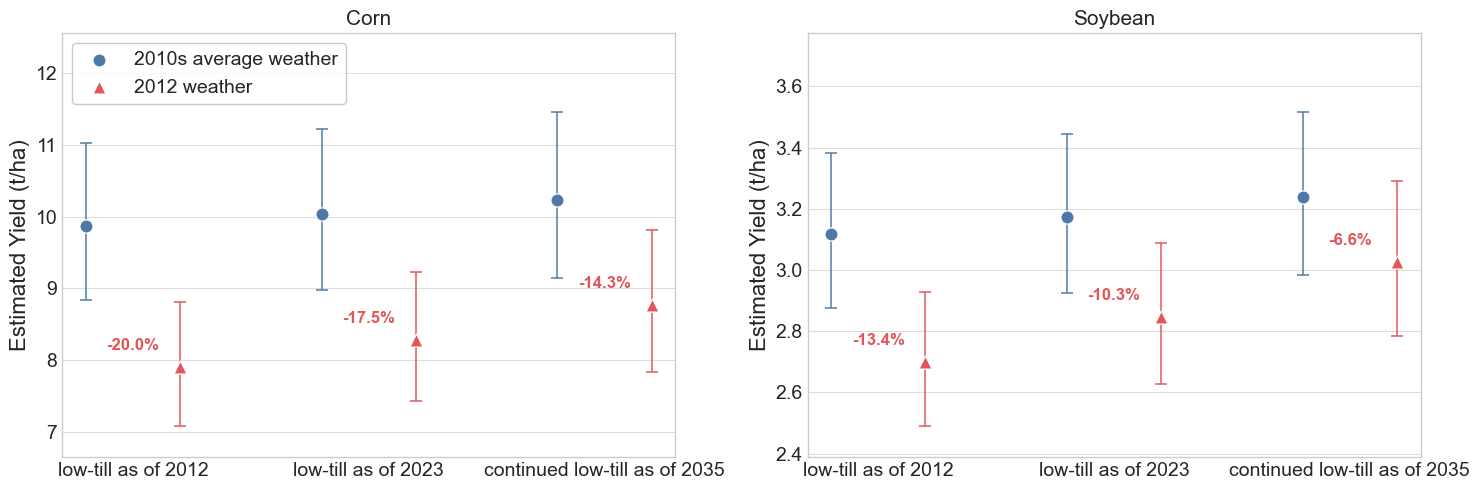

Saved: /Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex/output_scenario_1999_2023/drought_2012_weather_fitted_yields_duration_scenarios_no_irrigation/figures/fitted_yield_2012_vs_2010_2019_by_duration_without_no_low_till.png


In [10]:
WEATHER_STYLES = {
    "2010-2019 average weather": {
        "color": "#4E79A7",
        "marker": "o",
    },
    "2012 weather": {
        "color": "#E15759",
        "marker": "^",
    },
}

WEATHER_ORDER = [
    "2010-2019 average weather",
    "2012 weather",
]

DURATION_ORDER = [
    "2012 duration",
    "2023 duration",
    "Continued low till",
]


def plot_drought_scenarios_by_duration(summary, out_dir):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
    x = np.arange(len(DURATION_ORDER))

    offsets = {
        "2010-2019 average weather": -0.2,
        "2012 weather": 0.2,
    }

    for ax, crop_label in zip(axes, ["Corn", "Soybean"]):
        crop_data = summary.loc[summary["crop_label"].eq(crop_label)].copy()

        crop_data = crop_data.loc[
            crop_data["duration_scenario_label"].isin(DURATION_ORDER)
        ].copy()

        baseline = (
            crop_data.loc[
                crop_data["scenario_label"].eq("2010-2019 average weather")
            ]
            .set_index("duration_scenario_label")
            .reindex(DURATION_ORDER)
        )

        baseline_yield = baseline["area_weighted_fitted_yield"].to_numpy(float)

        for weather_label in WEATHER_ORDER:
            style = WEATHER_STYLES[weather_label]

            d = (
                crop_data.loc[crop_data["scenario_label"].eq(weather_label)]
                .set_index("duration_scenario_label")
                .reindex(DURATION_ORDER)
            )

            y = d["area_weighted_fitted_yield"].to_numpy(float)
            low = d["area_weighted_fitted_yield_ci_low"].to_numpy(float)
            high = d["area_weighted_fitted_yield_ci_high"].to_numpy(float)
            x_values = x + offsets[weather_label]

            ax.errorbar(
                x_values,
                y,
                yerr=np.vstack([
                    np.maximum(0, y - low),
                    np.maximum(0, high - y),
                ]),
                fmt="none",
                ecolor=style["color"],
                elinewidth=1.2,
                capsize=4,
                capthick=1.2,
                alpha=0.9,
                zorder=3,
            )

            weather_label_in_use = (
                "2010s average weather"
                if weather_label == "2010-2019 average weather"
                else "2012 weather"
            )

            ax.scatter(
                x_values,
                y,
                color=style["color"],
                marker=style["marker"],
                s=90,
                edgecolor="white",
                linewidth=0.9,
                label=weather_label_in_use,
                zorder=4,
            )

            if weather_label == "2012 weather":
                change_pct = np.where(
                    np.isfinite(baseline_yield) & (baseline_yield != 0),
                    100 * (y / baseline_yield - 1),
                    np.nan,
                )

                for x_pos, yield_value, pct in zip(x_values, y, change_pct):
                    if np.isfinite(yield_value) and np.isfinite(pct):
                        ax.annotate(
                            f"{pct:+.1f}%",
                            xy=(x_pos - 0.2, yield_value),
                            xytext=(0, 10),
                            textcoords="offset points",
                            ha="center",
                            va="bottom",
                            fontsize=12,
                            color=style["color"],
                            fontweight="bold",
                            annotation_clip=True,
                            zorder=5,
                        )

        all_low = pd.to_numeric(
            crop_data["area_weighted_fitted_yield_ci_low"],
            errors="coerce",
        ).to_numpy(float)

        all_high = pd.to_numeric(
            crop_data["area_weighted_fitted_yield_ci_high"],
            errors="coerce",
        ).to_numpy(float)

        all_low = all_low[np.isfinite(all_low)]
        all_high = all_high[np.isfinite(all_high)]

        if all_low.size and all_high.size:
            y_min = all_low.min()
            y_max = all_high.max()
            y_span = max(y_max - y_min, abs(y_max) * 0.05, 0.1)
            ax.set_ylim(y_min - 0.10 * y_span, y_max + 0.25 * y_span)

        ax.set_xlim(-0.30, len(DURATION_ORDER) - 1 + 0.30)
        ax.set_title(crop_label, fontsize=15)
        ax.set_xticks(x)
        ax.set_xticklabels(
            [
                "low-till as of 2012",
                "low-till as of 2023",
                "continued low-till as of 2035",
            ],
            fontsize=14,
        )
        ax.set_ylabel("Estimated Yield (t/ha)", fontsize=16)
        ax.tick_params(axis="y", labelsize=14)
        ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
        ax.grid(axis="x", visible=False)

    handles, labels = axes[0].get_legend_handles_labels()
    legend_items = dict(zip(labels, handles))

    axes[0].legend(
        legend_items.values(),
        legend_items.keys(),
        frameon=True,
        edgecolor="#BDBDBD",
        facecolor="white",
        loc="upper left",
        fontsize=14,
    )

    fig.tight_layout()

    out_path = out_dir / "fitted_yield_2012_vs_2010_2019_by_duration_without_no_low_till.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return out_path


scenario_figure = plot_drought_scenarios_by_duration(
    fitted_summary,
    FIGURE_DIR,
)

print(f"Saved: {scenario_figure}")